Cellule 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# Palette
BLEU   = "#1B3A6B"
OR     = "#D4A017"
VERT   = "#2E7D32"
ROUGE  = "#C62828"
GRIS   = "#ECEFF1"
BLEU_L = "#90CAF9"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 150,
})

print("Imports OK")

Imports OK


Cellule 2 — Simulation données protéomiques

In [2]:
# ─────────────────────────────────────────────────────────────
# Simulation cohérente avec Wagner et al. (2025) — STANISLAS
# N=1594, AUT=28% énergie, 78 protéines Olink inflammation
# ─────────────────────────────────────────────────────────────

N = 1594  # taille réelle de l'étude Wagner et al. (2025)
N_PROTEINS = 78  # panel Olink inflammation — Wagner et al. (2025)

# Score AUT — distribution Wagner et al. (2025)
aut_score = np.clip(np.random.normal(28, 12, N), 5, 70)

# Groupes faibles vs forts consommateurs AUT
aut_group = np.where(aut_score > np.percentile(aut_score, 75),
                     "Fort consommateur", "Faible consommateur")

# Noms de protéines simulées (panel Olink inflammation)
protein_names = [f"PROT_{i:03d}" for i in range(N_PROTEINS)]

# Protéines clés connues (Wagner et al. 2025 — FGF-19 significative)
protein_names[0]  = "FGF-19"
protein_names[1]  = "IL-6"
protein_names[2]  = "TNF-α"
protein_names[3]  = "CRP"
protein_names[4]  = "IL-1β"
protein_names[5]  = "CXCL-10"
protein_names[6]  = "MCP-1"
protein_names[7]  = "VEGF-A"
protein_names[8]  = "PICP"      # biomarqueur fibrose — Girerd et al. (2026)
protein_names[9]  = "NT-proBNP" # IC subclinique — He et al. (2025)
protein_names[10] = "GAL-9"     # Ravassa & Girerd et al. (2026)
protein_names[11] = "THBS-2"    # Ravassa & Girerd et al. (2026)

# Simulation des niveaux protéiques
# FGF-19 négativement associée à AUT (Wagner et al. 2025)
protein_matrix = np.random.normal(0, 1, (N, N_PROTEINS))
protein_matrix[:, 0] = -0.3 * aut_score + np.random.normal(0, 0.8, N)  # FGF-19
protein_matrix[:, 8] =  0.25 * aut_score + np.random.normal(0, 0.8, N) # PICP
protein_matrix[:, 9] =  0.2  * aut_score + np.random.normal(0, 0.8, N) # NT-proBNP
protein_matrix[:, 2] =  0.15 * aut_score + np.random.normal(0, 0.9, N) # TNF-α
protein_matrix[:, 3] =  0.18 * aut_score + np.random.normal(0, 0.9, N) # CRP

proteins_df = pd.DataFrame(protein_matrix, columns=protein_names)
proteins_df["aut_score"] = aut_score
proteins_df["aut_group"] = aut_group

print(f" Participants simulés : {N}")
print(f"Protéines Olink      : {N_PROTEINS}")
print(f" AUT moyen            : {aut_score.mean():.1f}% (SD={aut_score.std():.1f})")
print(f" Forts consommateurs  : {(aut_group=='Fort consommateur').sum()}")
print(f" Faibles consommateurs: {(aut_group=='Faible consommateur').sum()}")

 Participants simulés : 1594
Protéines Olink      : 78
 AUT moyen            : 28.6% (SD=11.6)
 Forts consommateurs  : 399
 Faibles consommateurs: 1195


Cellule 3 — LASSO sélection de variables

In [3]:
# ─────────────────────────────────────────────────────────────
# LASSO — sélection parcimonieuse des biomarqueurs
# Justification : p=78 protéines, cadre haut-dimensionnel
# Pénalité ℓ1 → annule les coefficients non informatifs
# ─────────────────────────────────────────────────────────────

X = proteins_df[protein_names].values
y = proteins_df["aut_score"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LassoCV — choix automatique de lambda par validation croisée
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso_cv.fit(X_scaled, y)

# Coefficients sélectionnés
coefs = pd.Series(lasso_cv.coef_, index=protein_names)
selected = coefs[coefs != 0].sort_values(key=abs, ascending=False)
zero_coefs = (coefs == 0).sum()

print(f" Lambda optimal       : {lasso_cv.alpha_:.4f}")
print(f" Protéines sélectionnées : {len(selected)} / {N_PROTEINS}")
print(f" Protéines annulées      : {zero_coefs}")
print(f"\nTop 10 biomarqueurs sélectionnés :")
print(selected.head(10).round(4))

 Lambda optimal       : 0.0696
 Protéines sélectionnées : 12 / 78
 Protéines annulées      : 66

Top 10 biomarqueurs sélectionnés :
FGF-19      -4.5317
PICP         3.0249
NT-proBNP    2.0901
CRP          1.3591
TNF-α        0.8782
PROT_020     0.0755
PROT_038    -0.0346
PROT_023    -0.0289
PROT_050     0.0110
PROT_018     0.0104
dtype: float64


Cellule 4 — Graphe de réseau protéomique

In [4]:
# ─────────────────────────────────────────────────────────────
# Analyse de réseau — protéines sélectionnées par LASSO
# Algorithme : corrélations de Pearson + seuillage
# Inspiré de : Girerd et al. (2026), Zheng et al. (2026)
# ─────────────────────────────────────────────────────────────

# Protéines sélectionnées uniquement
selected_proteins = selected.index.tolist()
X_selected = proteins_df[selected_proteins]

# Matrice de corrélation
corr_matrix = X_selected.corr()

# Construction du graphe — seuil corrélation > 0.15
G = nx.Graph()
G.add_nodes_from(selected_proteins)

for i in range(len(selected_proteins)):
    for j in range(i+1, len(selected_proteins)):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.15:
            G.add_edge(selected_proteins[i], selected_proteins[j],
                      weight=abs(corr),
                      sign="positive" if corr > 0 else "negative")

print(f"✅ Noeuds : {G.number_of_nodes()}")
print(f"✅ Arêtes : {G.number_of_edges()}")

✅ Noeuds : 12
✅ Arêtes : 10


Cellule 5 — Visualisation complète Axe 2

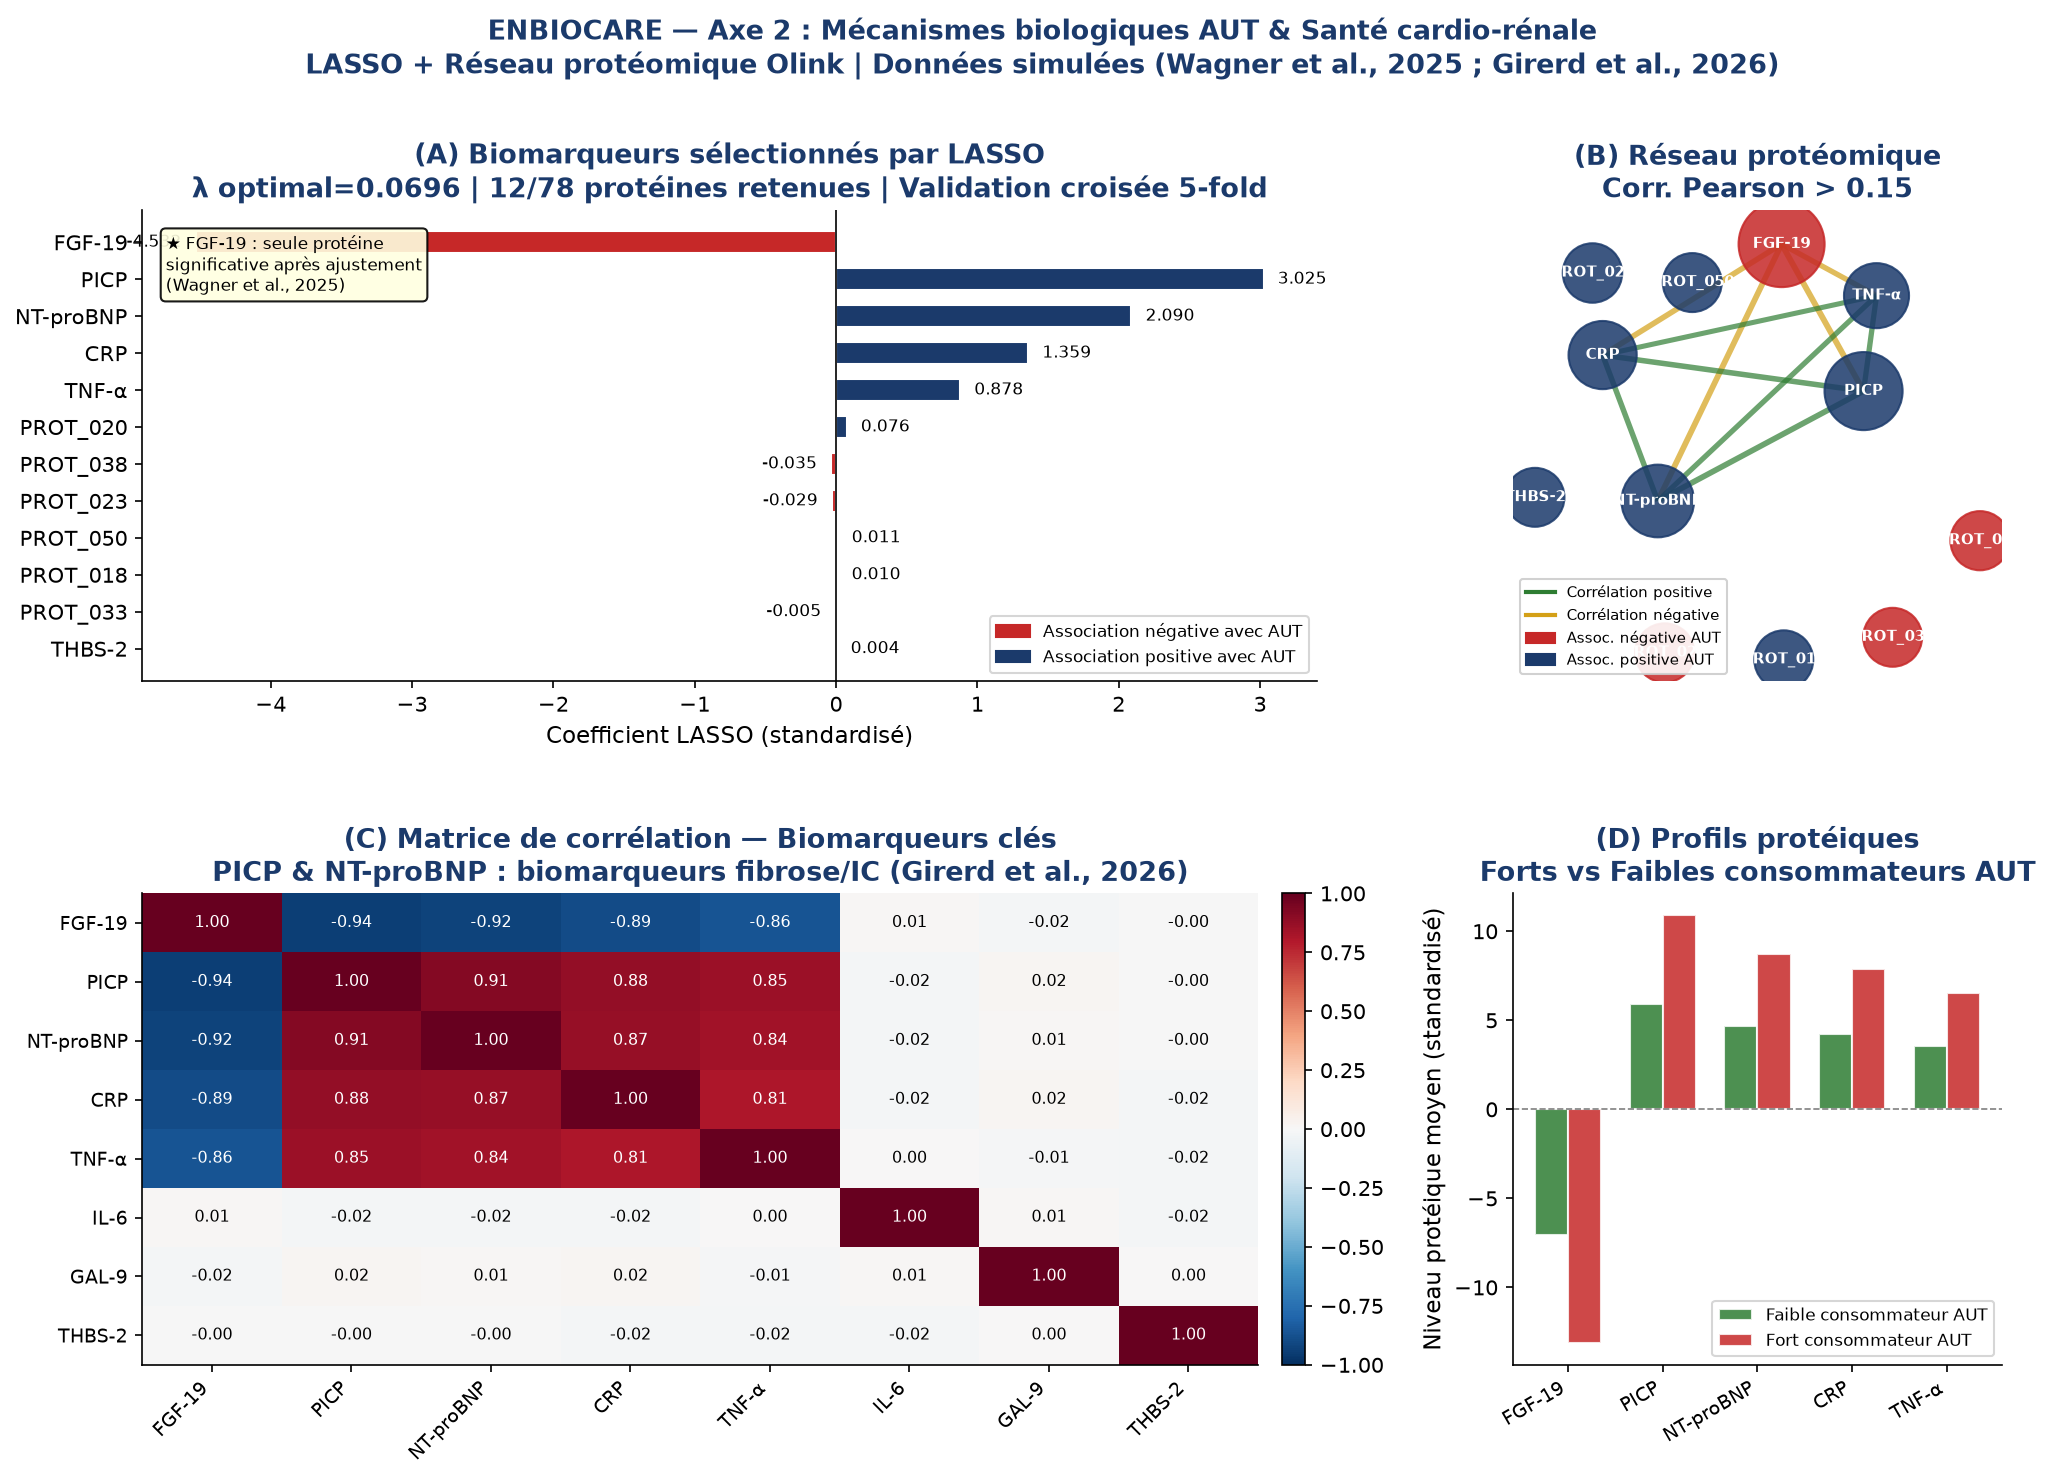

 Figure Axe 2 sauvegardée !


In [6]:

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("white")
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# ── (A) LASSO path — coefficients sélectionnés ───────────────
ax1 = fig.add_subplot(gs[0, :2])

colors_bar = [ROUGE if c < 0 else BLEU for c in selected.values]
bars = ax1.barh(selected.index[::-1], selected.values[::-1],
                color=colors_bar[::-1], height=0.6, edgecolor="white")
ax1.axvline(0, color="black", lw=0.8)
ax1.set_xlabel("Coefficient LASSO (standardisé)")
ax1.set_title(
    "(A) Biomarqueurs sélectionnés par LASSO\n"
    f"λ optimal={lasso_cv.alpha_:.4f} | "
    f"{len(selected)}/{N_PROTEINS} protéines retenues | "
    f"Validation croisée 5-fold",
    fontweight="bold", color=BLEU
)

# Annotations clés
for bar, (name, val) in zip(bars[::-1], selected.items()):
    ax1.text(val + (0.1 if val > 0 else -0.1), bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", ha="left" if val > 0 else "right",
             fontsize=8)

# Légende
neg_patch = mpatches.Patch(color=ROUGE, label="Association négative avec AUT")
pos_patch = mpatches.Patch(color=BLEU,  label="Association positive avec AUT")
ax1.legend(handles=[neg_patch, pos_patch], fontsize=8, loc="lower right")

# Annotation FGF-19
ax1.text(0.02, 0.95,
         "★ FGF-19 : seule protéine\nsignificative après ajustement\n(Wagner et al., 2025)",
         transform=ax1.transAxes, fontsize=8, va="top",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── (B) Réseau protéomique ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])

pos = nx.spring_layout(G, seed=42, k=2)

# Couleur noeuds selon coefficient LASSO
node_colors = []
node_sizes  = []
for node in G.nodes():
    coef = selected.get(node, 0)
    node_colors.append(ROUGE if coef < 0 else BLEU)
    node_sizes.append(800 + abs(coef) * 200)

# Arêtes
edge_colors  = []
edge_widths  = []
for u, v, data in G.edges(data=True):
    edge_colors.append(VERT if data["sign"] == "positive" else OR)
    edge_widths.append(data["weight"] * 3)

nx.draw_networkx_nodes(G, pos, ax=ax2,
                       node_color=node_colors,
                       node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G, pos, ax=ax2,
                       edge_color=edge_colors,
                       width=edge_widths, alpha=0.7)
nx.draw_networkx_labels(G, pos, ax=ax2, font_size=7,
                        font_color="white", font_weight="bold")

ax2.set_title("(B) Réseau protéomique\nCorr. Pearson > 0.15",
              fontweight="bold", color=BLEU)
ax2.axis("off")

# Légende réseau
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=VERT, lw=2, label="Corrélation positive"),
    Line2D([0], [0], color=OR,   lw=2, label="Corrélation négative"),
    mpatches.Patch(color=ROUGE, label="Assoc. négative AUT"),
    mpatches.Patch(color=BLEU,  label="Assoc. positive AUT"),
]
ax2.legend(handles=legend_elements, fontsize=7,
           loc="lower left", framealpha=0.9)

# ── (C) Heatmap corrélations protéines clés ──────────────────
ax3 = fig.add_subplot(gs[1, :2])

key_proteins = ["FGF-19", "PICP", "NT-proBNP", "CRP", "TNF-α",
                "IL-6", "GAL-9", "THBS-2"]
corr_key = proteins_df[key_proteins].corr()

im = ax3.imshow(corr_key.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax3.set_xticks(range(len(key_proteins)))
ax3.set_yticks(range(len(key_proteins)))
ax3.set_xticklabels(key_proteins, rotation=45, ha="right", fontsize=9)
ax3.set_yticklabels(key_proteins, fontsize=9)
plt.colorbar(im, ax=ax3, fraction=0.03, pad=0.02)

for i in range(len(key_proteins)):
    for j in range(len(key_proteins)):
        ax3.text(j, i, f"{corr_key.values[i,j]:.2f}",
                ha="center", va="center", fontsize=7.5,
                color="white" if abs(corr_key.values[i,j]) > 0.4 else "black")

ax3.set_title("(C) Matrice de corrélation — Biomarqueurs clés\n"
              "PICP & NT-proBNP : biomarqueurs fibrose/IC (Girerd et al., 2026)",
              fontweight="bold", color=BLEU)

# ── (D) Niveaux protéiques forts vs faibles consommateurs ────
ax4 = fig.add_subplot(gs[1, 2])

key_4 = ["FGF-19", "PICP", "NT-proBNP", "CRP", "TNF-α"]
fort   = proteins_df[proteins_df["aut_group"]=="Fort consommateur"][key_4].mean()
faible = proteins_df[proteins_df["aut_group"]=="Faible consommateur"][key_4].mean()

x = np.arange(len(key_4))
w = 0.35
ax4.bar(x - w/2, faible.values, w, label="Faible consommateur AUT",
        color=VERT, alpha=0.85, edgecolor="white")
ax4.bar(x + w/2, fort.values,   w, label="Fort consommateur AUT",
        color=ROUGE, alpha=0.85, edgecolor="white")
ax4.set_xticks(x)
ax4.set_xticklabels(key_4, rotation=30, ha="right", fontsize=9)
ax4.set_ylabel("Niveau protéique moyen (standardisé)")
ax4.set_title("(D) Profils protéiques\nForts vs Faibles consommateurs AUT",
              fontweight="bold", color=BLEU)
ax4.legend(fontsize=8)
ax4.axhline(0, color="gray", lw=0.8, ls="--")

# ── Titre global ─────────────────────────────────────────────
fig.suptitle(
    "ENBIOCARE — Axe 2 : Mécanismes biologiques AUT & Santé cardio-rénale\n"
    "LASSO + Réseau protéomique Olink | Données simulées (Wagner et al., 2025 ; Girerd et al., 2026)",
    fontsize=13, fontweight="bold", color=BLEU, y=1.01
)

import matplotlib.patches as mpatches
plt.tight_layout()
plt.savefig("../figures/axe2_figure.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Figure Axe 2 sauvegardée !")